# Incidents Table EDA

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE_DIR = Path('..').resolve() / 'data'
incidents = pd.read_parquet(BASE_DIR / 'incidents.parquet').copy()

for c in ['occurred_at', 'reported_at', 'created_at']:
    if c in incidents.columns:
        incidents[c] = pd.to_datetime(incidents[c], errors='coerce')

if 'occurred_at' not in incidents.columns:
    fallback = 'reported_at' if 'reported_at' in incidents.columns else 'created_at'
    incidents['occurred_at'] = incidents[fallback]

print('shape:', incidents.shape)
incidents.head()


shape: (3578, 8)


,incident_id,facility_id,resident_id,incident_type,incident_location,occurred_at,strikeout,created_at
0,0d32dafc-e91c-5360-aefd-55e0f98943d6,0240d706-3348-5117-8d03-b06c5141e8c0,e681d7c1-a733-57cf-86cd-fd57e3b02f39,Fall,Resident's Room,2024-11-13 05:10:00,False,2024-11-13 05:45:31.053
1,447f3407-8ccb-5e86-8469-7e0af5314ade,0240d706-3348-5117-8d03-b06c5141e8c0,207a6546-03d7-5343-a214-299291a28151,Fall,Resident's Room,2024-10-09 17:47:00,False,2024-10-09 17:48:02.573
2,4860a3b6-9edf-53ec-841a-1c5a15b84709,0240d706-3348-5117-8d03-b06c5141e8c0,725efbae-bafc-53a6-bfa5-ff3ad771f447,Fall,Dining Room,2024-08-09 20:31:00,False,2024-08-10 07:32:38.360
3,fc29a329-6305-597f-94df-2b4b81ca8b76,0240d706-3348-5117-8d03-b06c5141e8c0,0dc1285a-6858-543e-9c46-202e9b82a328,Fall,Resident's Room,2024-11-28 20:50:00,False,2024-11-28 21:04:13.683
4,32c20bda-59f7-5aa0-ba20-250fe9aa9c45,0240d706-3348-5117-8d03-b06c5141e8c0,207a6546-03d7-5343-a214-299291a28151,Fall,Resident's Room,2024-09-28 18:20:00,False,2024-09-28 18:20:24.140


In [2]:
summary = {
    'rows': len(incidents),
    'unique_incidents': incidents['incident_id'].nunique() if 'incident_id' in incidents.columns else np.nan,
    'unique_residents': incidents['resident_id'].nunique() if 'resident_id' in incidents.columns else np.nan,
    'unique_facilities': incidents['facility_id'].nunique() if 'facility_id' in incidents.columns else np.nan,
    'occurred_min': incidents['occurred_at'].min() if 'occurred_at' in incidents.columns else pd.NaT,
    'occurred_max': incidents['occurred_at'].max() if 'occurred_at' in incidents.columns else pd.NaT,
}
pd.Series(summary)


rows                                3578
unique_incidents                    3578
unique_residents                     987
unique_facilities                     92
occurred_min         2019-01-10 08:17:00
occurred_max         2025-01-31 22:40:00
dtype: object

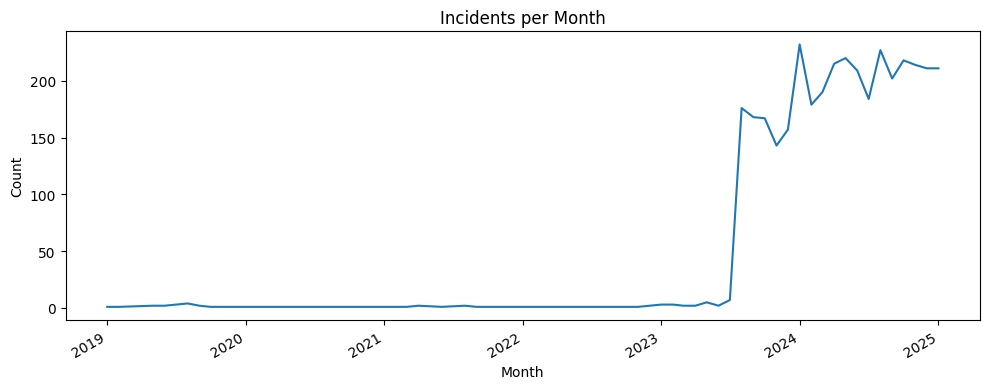

In [3]:
# Incidents per month
if 'occurred_at' in incidents.columns:
    d = incidents.dropna(subset=['occurred_at']).copy()
    d['month'] = d['occurred_at'].dt.to_period('M').dt.to_timestamp()
    s = d.groupby('month').size()

    fig, ax = plt.subplots(figsize=(10, 4))
    s.plot(ax=ax)
    ax.set_title('Incidents per Month')
    ax.set_xlabel('Month')
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()


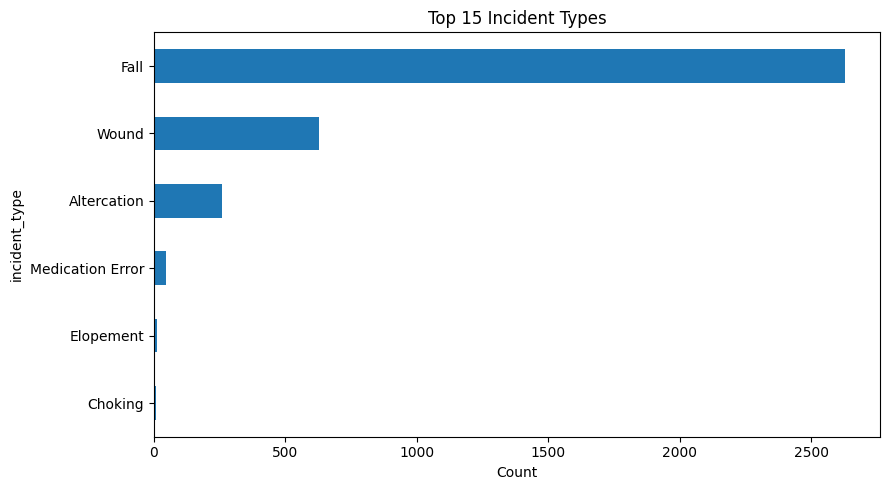

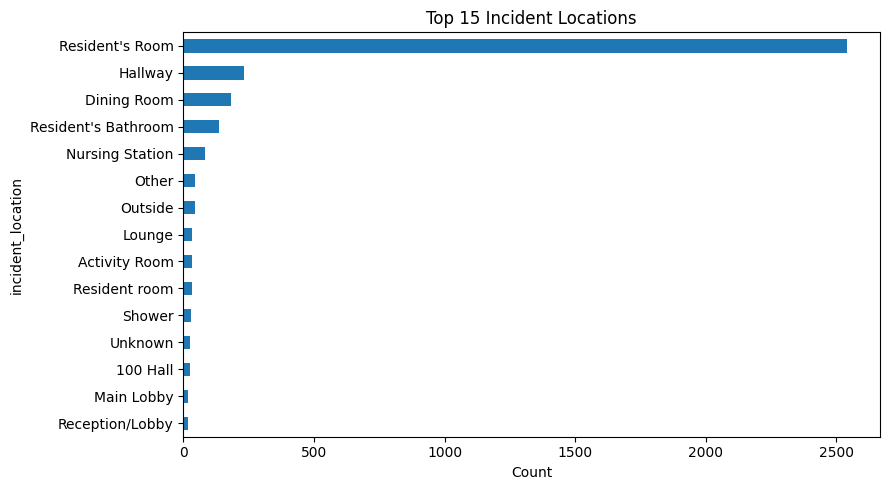

In [4]:
# Top incident types and locations
if 'incident_type' in incidents.columns:
    t = incidents['incident_type'].fillna('Unknown').value_counts().head(15).sort_values()
    fig, ax = plt.subplots(figsize=(9, 5))
    t.plot(kind='barh', ax=ax)
    ax.set_title('Top 15 Incident Types')
    ax.set_xlabel('Count')
    plt.tight_layout()
    plt.show()

if 'incident_location' in incidents.columns:
    l = incidents['incident_location'].fillna('Unknown').value_counts().head(15).sort_values()
    fig, ax = plt.subplots(figsize=(9, 5))
    l.plot(kind='barh', ax=ax)
    ax.set_title('Top 15 Incident Locations')
    ax.set_xlabel('Count')
    plt.tight_layout()
    plt.show()


In [ ]:
# Day-of-week and hour patterns
if 'occurred_at' in incidents.columns:
    d = incidents.dropna(subset=['occurred_at']).copy()
    d['dow'] = d['occurred_at'].dt.day_name()
    d['hour'] = d['occurred_at'].dt.hour

    dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    dow_counts = d['dow'].value_counts().reindex(dow_order)

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    dow_counts.plot(kind='bar', ax=axes[0])
    axes[0].set_title('Incidents by Day of Week')
    axes[0].set_xlabel('Day')
    axes[0].set_ylabel('Count')

    axes[1].hist(d['hour'].dropna(), bins=24, range=(0, 24), alpha=0.8)
    axes[1].set_title('Incidents by Hour of Day')
    axes[1].set_xlabel('Hour')
    axes[1].set_ylabel('Count')

    plt.tight_layout()
    plt.show()
